In [ ]:
import os, sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("cwd:", os.getcwd())
print("root:", PROJECT_ROOT)


In [63]:
from pathlib import Path
import os, sys

PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), "../..")))
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = (PROJECT_ROOT/ "data" / "bundle_pricing").resolve()

print("cwd:", os.getcwd())
print("root:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("xdf files found:", len(list(DATA_DIR.glob("*.xdf"))))


cwd: c:\Users\Gamge\Desktop\event-related-potentials-1\notebooks\bundle_pricing
root: c:\Users\Gamge\Desktop\event-related-potentials-1
DATA_DIR: C:\Users\Gamge\Desktop\event-related-potentials-1\data\bundle_pricing
xdf files found: 4


In [64]:
import matplotlib.pyplot as plt
import numpy as np
import mne
import pandas as pd
import os
from src.UnicornData import UnicornData
from pathlib import Path

In [81]:
# DATA_DIR = Path("../../data/bundle_pricing").resolve()
CSV_SKIPROWS = 1
CSV_SKIPFOOTER = 6
DELAY_SECONDS = 0.073  # your photodiode delay

PICKS = ["Cz", "Pz"]
TMIN, TMAX = -0.2, 1.0

# LPP window
LPP_TMIN, LPP_TMAX = 0.4, 0.6

# Markers
MARKER_BUNDLE_PRICE_NP = 31
MARKER_BUNDLE_PRICE_LP = 32
MARKER_BUNDLE_PRICE_ZP = 33

EVENT_DICT = dict(lp=MARKER_BUNDLE_PRICE_LP, np=MARKER_BUNDLE_PRICE_NP, zp=MARKER_BUNDLE_PRICE_ZP)

# Reject criteria (yours)
# REJECT_CRITERIA = dict(eeg=150e-6)


# ---------------- DISCOVER FILES ----------------
xdf_files = sorted(DATA_DIR.glob("*.xdf"))
if not xdf_files:
    raise SystemExit(f"No .xdf files found in: {DATA_DIR}")

all_trials = []      # per-trial CSVs with EEG features appended
all_summaries = []   # per-file summary tables
manifest = []        # status tracking
evokeds_by_subject = {}

for xdf_path in xdf_files:
    stem = xdf_path.stem
    csv_path = xdf_path.with_suffix(".csv")

    if not csv_path.exists():
        manifest.append({"stem": stem, "status": "SKIP", "reason": "CSV not found"})
        continue

    try:
        # ---- read CSV ----
        csv_data = pd.read_csv(
            csv_path,
            skiprows=CSV_SKIPROWS,
            skipfooter=CSV_SKIPFOOTER,
            engine="python",
        )

        # ---- load XDF ----
        data = UnicornData(str(xdf_path), delay=DELAY_SECONDS)

        # ---- epochs ----
        epochs = data.create_epochs(
            picks=PICKS,
            event_dict=EVENT_DICT,
            tmin=TMIN,
            tmax=TMAX
            # reject_criteria=REJECT_CRITERIA
        )

        # --- align: keep only non-rejected epochs in BOTH epochs & csv ---
        drop_log = epochs.drop_log
        drop_log_not_ignored = [log for log in drop_log if "IGNORED" not in log]
        good_epoch_idx = [i for i, log in enumerate(drop_log_not_ignored) if len(log) == 0]


        # Keep only good trials (same logic you used)
        epochs_good = epochs[good_epoch_idx]
        csv_good = csv_data.iloc[good_epoch_idx].reset_index(drop=True)
        evoked_np = epochs_good["np"].average() if "np" in epochs_good.event_id else None
        evoked_zp = epochs_good["zp"].average() if "zp" in epochs_good.event_id else None
        evoked_lp = epochs_good["lp"].average() if "lp" in epochs_good.event_id else None

    # --- store them per subject ---
        evokeds_by_subject[stem] = {}

        if evoked_np is not None:
            evokeds_by_subject[stem]["NP"] = evoked_np
        if evoked_zp is not None:
            evokeds_by_subject[stem]["ZP"] = evoked_zp
        if evoked_lp is not None:
            evokeds_by_subject[stem]["LP"] = evoked_lp

        mask = csv_good["valid_response"] == 1
        epochs_good = epochs_good[mask.values]   # filter EEG
        csv_good = csv_good[mask].reset_index(drop=True)  #

        # ---- compute per-trial LPP for Cz/Pz ----
        # epochs_good.get_data(picks=...) returns shape: (n_epochs, n_channels, n_times)
        lpp = epochs_good.copy().crop(LPP_TMIN, LPP_TMAX).get_data(picks=PICKS).mean(axis=2)
        # lpp shape: (n_epochs, 2) => [Cz_mean, Pz_mean]
        csv_good["Cz_LPP_400_600ms"] = lpp[:, 0]
        csv_good["Pz_LPP_400_600ms"] = lpp[:, 1]

        # ---- add identifiers ----
        csv_good.insert(0, "stem", stem)
        csv_good.insert(1, "xdf_filename", xdf_path.name)
        csv_good.insert(2, "csv_filename", csv_path.name)

        all_trials.append(csv_good)

        # ---- per-file summary (optional) ----
        summary = (
            csv_good[csv_good.get("valid_response", 1) == 1]
            .groupby("condition")
            .agg(
                mean_Cz_LPP_400_600ms=("Cz_LPP_400_600ms", "mean"),
                mean_Pz_LPP_400_600ms=("Pz_LPP_400_600ms", "mean"),
                mean_response_time_ms=("rt_ms", "mean"),
                total_spent=("total_price", "sum"),
                mean_spent=("total_price", "mean"),
                total_trials=("response", "count"),
                total_bought=("response", lambda x: list(x).count("BUY")),
                purchase_rate=("response", lambda x: list(x).count("BUY") / len(x) * 100),
            )
            .reset_index()
        )
        summary.insert(0, "stem", stem)
        all_summaries.append(summary)

        manifest.append({
            "stem": stem,
            "status": "OK",
            "n_csv_rows": len(csv_data),
            "n_epochs_total": len(epochs),
            "n_epochs_good": len(epochs_good),
        })

        print(f"OK | {stem} | csv={len(csv_data)} | epochs={len(epochs)} | kept={len(epochs_good)}")

    except Exception as e:
        manifest.append({"stem": stem, "status": "FAIL", "reason": str(e)})
        print(f"FAIL | {stem} | {e}")

# ---------------- CONCATENATE ACROSS ALL FILES ----------------
combined_trials = pd.concat(all_trials, ignore_index=True) if all_trials else pd.DataFrame()

combined_summaries = pd.concat(all_summaries, ignore_index=True) if all_summaries else pd.DataFrame()
manifest_df = pd.DataFrame(manifest)

print("\n--- Manifest ---")
print(manifest_df)

print("\n--- Combined trials head ---")
print(combined_trials.head())

print("\n--- Combined summaries head ---")
print(combined_summaries.head())

Markers 481
Data 0
Data 191787
Creating RawArray with float64 data, n_channels=8, n_times=191787
    Range : 0 ... 191786 =      0.000 ...   767.144 secs
Ready.
FAIL | bundle_pricing_2_dato | Event time samples were not unique. Consider setting the `event_repeated` parameter."
Data 288350
Markers 481
Creating RawArray with float64 data, n_channels=8, n_times=288350
    Range : 0 ... 288349 =      0.000 ...  1153.396 secs
Ready.
Not setting metadata
120 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 120 events and 301 original time points ...
0 bad epochs dropped
OK | bundle_pricing_3_beqa | csv=120 | epochs=120 | kept=119
Data 286975
Markers 481
Creating RawArray with float64 data, n_channels=8, n_times=286975
    Range : 0 ... 286974 =      0.000 ...  1147.896 secs
Ready.
Not setting metadata
120 matching events found
Setting baseline interval to [-0.2, 0.0] s
App

In [72]:
evokeds_by_subject = {"NP": evoked_np, "ZP": evoked_zp, "LP": evoked_lp}
evokeds_by_subject

{'NP': <Evoked | 'np' (average, N=40), -0.2 – 1 s, baseline -0.2 – 0 s, 2 ch, ~15 KiB>,
 'ZP': <Evoked | 'zp' (average, N=40), -0.2 – 1 s, baseline -0.2 – 0 s, 2 ch, ~15 KiB>,
 'LP': <Evoked | 'lp' (average, N=40), -0.2 – 1 s, baseline -0.2 – 0 s, 2 ch, ~15 KiB>}

In [66]:
combined_trials

,stem,xdf_filename,csv_filename,timestamp_iso,participant_id,age,response_group,trial_index,block,bundle_id,...,total_price,allocation_per_trial,response_key,response,rt_ms,valid_response,is_selected_bundle,bundles_bought_cumulative,Cz_LPP_400_600ms,Pz_LPP_400_600ms
0,bundle_pricing_3_beqa,bundle_pricing_3_beqa.xdf,bundle_pricing_3_beqa.csv,2026-01-15T07:39:54.004,3,26,A,0,1,9,...,4.53,70.0,num_3,NOBUY,1101.62,1,0,0,-0.000024,0.000010
1,bundle_pricing_3_beqa,bundle_pricing_3_beqa.xdf,bundle_pricing_3_beqa.csv,2026-01-15T07:40:01.497,3,26,A,1,1,26,...,55.98,70.0,num_3,NOBUY,483.40,1,0,0,-0.000017,-0.000016
2,bundle_pricing_3_beqa,bundle_pricing_3_beqa.xdf,bundle_pricing_3_beqa.csv,2026-01-15T07:40:16.784,3,26,A,3,1,29,...,43.25,70.0,num_3,NOBUY,648.57,1,1,0,-0.000026,-0.000037
3,bundle_pricing_3_beqa,bundle_pricing_3_beqa.xdf,bundle_pricing_3_beqa.csv,2026-01-15T07:40:24.427,3,26,A,4,1,25,...,44.56,70.0,num_1,BUY,773.13,1,0,1,-0.000017,0.000005
4,bundle_pricing_3_beqa,bundle_pricing_3_beqa.xdf,bundle_pricing_3_beqa.csv,2026-01-15T07:40:32.120,3,26,A,5,1,27,...,55.17,70.0,num_1,BUY,1568.45,1,0,2,-0.000017,-0.000012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,bundle_pricing_5_saata,bundle_pricing_5_saata.xdf,bundle_pricing_5_saata.csv,2026-01-15T08:58:20.159,5,26,A,115,3,22,...,13.86,70.0,num_1,BUY,1747.45,1,0,50,-0.000058,-0.000059
347,bundle_pricing_5_saata,bundle_pricing_5_saata.xdf,bundle_pricing_5_saata.csv,2026-01-15T08:58:27.735,5,26,A,116,3,12,...,23.48,70.0,num_3,NOBUY,906.58,1,0,50,-0.000083,-0.000076
348,bundle_pricing_5_saata,bundle_pricing_5_saata.xdf,bundle_pricing_5_saata.csv,2026-01-15T08:58:35.262,5,26,A,117,3,20,...,44.86,70.0,num_3,NOBUY,1329.18,1,0,50,-0.000057,-0.000054
349,bundle_pricing_5_saata,bundle_pricing_5_saata.xdf,bundle_pricing_5_saata.csv,2026-01-15T08:58:42.839,5,26,A,118,3,13,...,47.92,70.0,num_3,NOBUY,2096.22,1,0,50,-0.000092,-0.000093


### Purchase Rate

In [19]:
subject_rates = (
    combined_trials
    .assign(buy=lambda df: (df["response"] == "BUY").astype(int))
    .groupby(["participant_id", "condition"])
    .agg(purchase_rate=("buy", "mean"))
    .reset_index()
)

In [20]:
import pingouin as pg

aov = pg.rm_anova(
    data=subject_rates,
    dv="purchase_rate",
    within="condition",
    subject="participant_id",
    detailed=True
)

aov
# Does purchase rate differ across price frames?

,Source,SS,DF,MS,F,p-unc,ng2,eps
0,condition,0.007616,2,0.003808,0.520589,0.629587,0.196341,0.843555
1,Error,0.029260,4,0.007315,NaN,NaN,NaN,NaN


In [28]:
posthoc_pr = pg.pairwise_tests(
    data=subject_rates,
    dv="purchase_rate",
    within="condition",
    subject="participant_id",
    padjust="bonf"
)

posthoc_pr[["A", "B", "T", "p-corr", "hedges"]]
# Which specific pairs of conditions differ

,A,B,T,p-corr,hedges
0,LP,NP,0.060993,1.0,0.050765
1,LP,ZP,-1.004655,1.0,-0.619724
2,NP,ZP,-0.762990,1.0,-0.667075


In [29]:
def add_sig_bracket(ax, x1, x2, y, h, text):
    """
    Draws a significance bracket between bars x1 and x2.
    """
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, color="black")
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom", fontsize=9)

def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return None


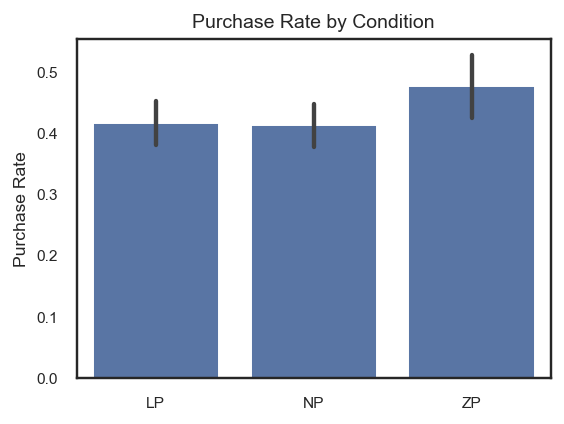

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="white")  

plt.figure(figsize=(4, 3), dpi=140)

ax = sns.barplot(
    data=subject_rates,
    x="condition",
    y="purchase_rate",
    errorbar="se"
)

cond_order = ["NP", "ZP", "LP"]
y_max = ax.get_ylim()[1]
step = y_max * 0.05
y = y_max * 0.95


for _, row in posthoc_pr.iterrows():
    stars = p_to_stars(row["p-corr"])
    if stars is None:
        continue

    a, b = row["A"], row["B"]
    if a not in cond_order or b not in cond_order:
        continue

    x1 = cond_order.index(a)
    x2 = cond_order.index(b)

    add_sig_bracket(ax, min(x1, x2), max(x1, x2), y, step, stars)
    y += step * 1.5  # move up for next bracket


ax.set_xlabel("")  # remove "condition" label
ax.set_title("Purchase Rate by Condition", fontsize=10)
ax.set_ylabel("Purchase Rate", fontsize=9)
ax.tick_params(axis="both", labelsize=8)

plt.tight_layout(pad=0.5)
plt.show()




In [44]:
subject_rt = (
    combined_trials
    .groupby(["participant_id", "condition"])
    .agg(mean_rt=("rt_ms", "mean"))
    .reset_index()
)


aov_rt = pg.rm_anova(
    data=subject_rt,
    dv="mean_rt",
    within="condition",
    subject="participant_id",
    detailed=True
)

# aov_rt

posthoc_rt = pg.pairwise_tests(
    data=subject_rt,
    dv="mean_rt",
    within="condition",
    subject="participant_id",
    padjust="bonf"
)

posthoc_rt[["A", "B", "T", "p-corr", "hedges"]]

,A,B,T,p-corr,hedges
0,LP,NP,-1.568212,0.772113,-0.132113
1,LP,ZP,-1.828761,0.626823,-0.188606
2,NP,ZP,-0.917172,1.000000,-0.055711


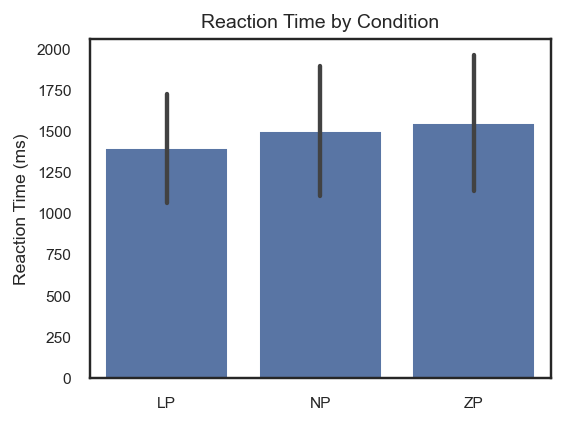

In [ ]:
plt.figure(figsize=(4, 3), dpi=140)

ax = sns.barplot(
    data=subject_rt,
    x="condition",
    y="mean_rt",
    errorbar="se"
)

cond_order = ["NP", "ZP", "LP"]
y_max = ax.get_ylim()[1]
step = y_max * 0.05
y = y_max * 0.95


for _, row in posthoc_pr.iterrows():
    stars = p_to_stars(row["p-corr"])
    if stars is None:
        continue

    a, b = row["A"], row["B"]
    if a not in cond_order or b not in cond_order:
        continue

    x1 = cond_order.index(a)
    x2 = cond_order.index(b)

    add_sig_bracket(ax, min(x1, x2), max(x1, x2), y, step, stars)
    y += step * 1.5 


ax.set_xlabel("")  
ax.set_title("Reaction Time by Condition", fontsize=10)
ax.set_ylabel("Reaction Time (ms)", fontsize=9)
ax.tick_params(axis="both", labelsize=8)

plt.tight_layout(pad=0.5)
plt.show()


In [51]:

df = combined_trials.copy()


# subject-level mean LPP per condition (average across trials)
subj_lpp = (
    df.groupby(["participant_id", "condition"], as_index=False)
      .agg(Cz=("Cz_LPP_400_600ms", "mean"),
           Pz=("Pz_LPP_400_600ms", "mean"))
)

# convert wide -> long electrode factor
subj_lpp_long = subj_lpp.melt(
    id_vars=["participant_id", "condition"],
    value_vars=["Cz", "Pz"],
    var_name="electrode",
    value_name="lpp_v"
)

# (optional) convert to µV for reporting like the paper
subj_lpp_long["lpp_uv"] = subj_lpp_long["lpp_v"] * 1e6


aov_lpp = pg.rm_anova(
    data=subj_lpp_long,
    dv="lpp_uv",                 # use µV
    within=["condition", "electrode"],
    subject="participant_id",
    detailed=True
)
print(aov_lpp)


                  Source          SS  ddof1  ddof2          MS           F  \
0              condition   82.615629      2      4   41.307815    0.425835   
1              electrode  150.521012      1      2  150.521012  253.647055   
2  condition * electrode    1.725028      2      4    0.862514    2.352706   

      p-unc  p-GG-corr       ng2       eps  
0  0.679731   0.593349  0.036737  0.547932  
1  0.003919   0.003919  0.064971  1.000000  
2  0.211126   0.229271  0.000796  0.812601  


c:\Users\Gamge\anaconda3\envs\pvt\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\Gamge\anaconda3\envs\pvt\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


In [ ]:
# subj_cond = (
#     subj_lpp_long.groupby(["participant_id", "condition"], as_index=False)
#                  .agg(lpp_uv=("lpp_uv", "mean"))   # average Cz & Pz
# )

# aov_cond = pg.rm_anova(data=subj_cond, dv="lpp_uv", within="condition", subject="participant_id", detailed=True)
# posthoc_cond = pg.pairwise_tests(data=subj_cond, dv="lpp_uv", within="condition", subject="participant_id", padjust="bonf")

# aov_cond
# print(posthoc_cond[["A","B","T","p-corr","hedges"]])


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,condition,41.307815,2,20.653907,0.425835,0.679731,0.036781,0.547932
1,Error,194.008422,4,48.502105,NaN,NaN,NaN,NaN


In [ ]:
# posthoc_cond[["A","B","T","p-corr","hedges"]]

,A,B,T,p-corr,hedges
0,LP,NP,0.631622,1.0,0.258333
1,LP,ZP,0.669660,1.0,0.304832
2,NP,ZP,0.602112,1.0,0.095301


Setting up low-pass filter at 15 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 15.00 Hz
- Upper transition bandwidth: 3.75 Hz (-6 dB cutoff frequency: 16.88 Hz)
- Filter length: 221 samples (0.884 s)

Setting up low-pass filter at 15 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 15.00 Hz
- Upper transition bandwidth: 3.75 Hz (-6 dB cutoff frequency: 16.88 Hz)
- Filter length: 221 samples (0.884 s)

Setting up low-pass filter at 15 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) m

C:\Users\Gamge\AppData\Local\Temp\ipykernel_12452\2429252494.py:21: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(
C:\Users\Gamge\AppData\Local\Temp\ipykernel_12452\2429252494.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.6)


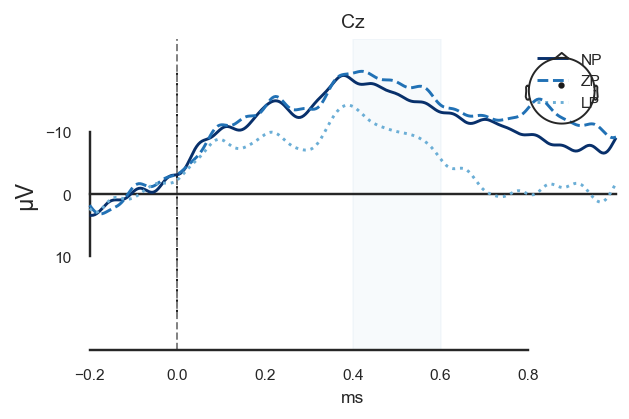

In [ ]:

def smooth_evoked(ev, h_freq=15):
    return ev.copy().filter(None, h_freq)

# Use smoothed copies only for plotting
grand_plot = {k: smooth_evoked(v) for k, v in grand.items()}

blue_colors = {
    "NP": "#08306B",  
    "ZP": "#2171B5",  
    "LP": "#6BAED6"   
}

linestyles = {"NP": "-", "ZP": "--", "LP": ":"}

fig, ax = plt.subplots(figsize=(4.5, 3), dpi=140)

mne.viz.plot_compare_evokeds(
    grand_plot,
    picks=["Cz"],
    combine="mean",
    axes=ax,
    show=False,
    colors=blue_colors,
    linestyles=linestyles
)

ax.axvspan(0.4, 0.6, alpha=0.12, color="#BFD7EA")  # LPP window
ax.axvline(0, linestyle="--", color="gray", linewidth=1)  # stimulus onset
ax.set_ylim(-25, 25) 
ax.set_title("Cz", fontsize=10)
ax.set_xlabel("ms", fontsize=9)
ax.tick_params(labelsize=8)
ax.invert_yaxis()  # ERP convention
ax.legend(frameon=False, fontsize=8, loc="upper right")

plt.tight_layout(pad=0.6)
plt.show()



Setting up low-pass filter at 15 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 15.00 Hz
- Upper transition bandwidth: 3.75 Hz (-6 dB cutoff frequency: 16.88 Hz)
- Filter length: 221 samples (0.884 s)

Setting up low-pass filter at 15 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 15.00 Hz
- Upper transition bandwidth: 3.75 Hz (-6 dB cutoff frequency: 16.88 Hz)
- Filter length: 221 samples (0.884 s)

Setting up low-pass filter at 15 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) m

C:\Users\Gamge\AppData\Local\Temp\ipykernel_12452\3280629627.py:13: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(
C:\Users\Gamge\AppData\Local\Temp\ipykernel_12452\3280629627.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.6)


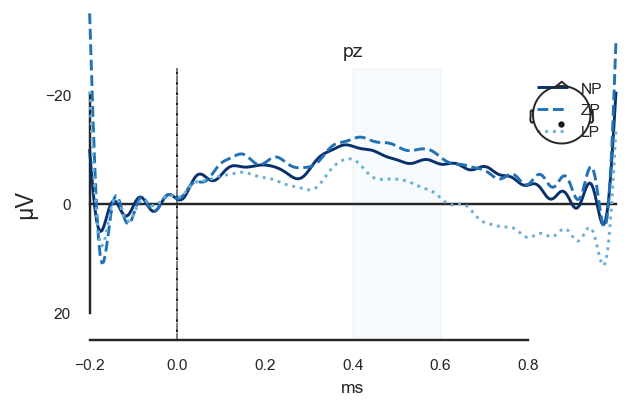

In [100]:
grand_plot = {k: smooth_evoked(v) for k, v in grand.items()}

blue_colors = {
    "NP": "#08306B",  
    "ZP": "#2171B5",  
    "LP": "#6BAED6"   
}

linestyles = {"NP": "-", "ZP": "--", "LP": ":"}

fig, ax = plt.subplots(figsize=(4.5, 3), dpi=140)

mne.viz.plot_compare_evokeds(
    grand_plot,
    picks=["Pz"],
    combine="mean",
    axes=ax,
    show=False,
    colors=blue_colors,
    linestyles=linestyles
)

ax.axvspan(0.4, 0.6, alpha=0.12, color="#BFD7EA")  
ax.axvline(0, linestyle="--", color="gray", linewidth=1) 
ax.set_ylim(-25, 25) 
ax.set_title("pz", fontsize=10)
ax.set_xlabel("ms", fontsize=9)
ax.tick_params(labelsize=8)
ax.invert_yaxis()  # ERP convention
ax.legend(frameon=False, fontsize=8, loc="upper right")

plt.tight_layout(pad=0.6)
plt.show()



In [103]:
df["LPP_mean"] = df[["Cz_LPP_400_600ms", "Pz_LPP_400_600ms"]].mean(axis=1)
subject_corr = (
    df.groupby(["stem", "condition"], as_index=False)
      .agg(
          LPP=("LPP_mean", "mean"),
          RT=("rt_ms", "mean")
      )
)



In [104]:
from scipy.stats import pearsonr

results = {}

for cond in ["NP", "ZP", "LP"]:
    sub = subject_corr[subject_corr["condition"] == cond]
    r, p = pearsonr(sub["LPP"], sub["RT"])
    results[cond] = (r, p)
    print(f"{cond}: r = {r:.3f}, p = {p:.3f}")



NP: r = -0.602, p = 0.589
ZP: r = -0.614, p = 0.579
LP: r = -0.050, p = 0.968
